In [28]:
!pip install torch


In [29]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1000, 100)
        self.fc2 = nn.Linear(100, 50)
        self.fc3 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

model = SimpleNN()
model.to("cuda")

SimpleNN(
  (fc1): Linear(in_features=1000, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=10, bias=True)
)

In [30]:
def human_readable_time(seconds):
    """
    Converts a time duration in seconds into a human readable string.
    """
    if seconds < 1e-6:
        return f"{seconds*1e9:.2f} ns"
    elif seconds < 1e-3:
        return f"{seconds*1e6:.2f} μs"
    elif seconds < 1:
        return f"{seconds*1e3:.2f} ms"
    else:
        return f"{seconds:.3f} s"

In [31]:
import torch

backends = [
    "eager",
    "aot_eager",
    "inductor",
    "cudagraphs"
]

model_eager = torch.compile(model, backend="eager")
model_aot_eager = torch.compile(model, backend="aot_eager")
model_inductor = torch.compile(model, backend="inductor")
model_cudagraphs = torch.compile(model, backend="cudagraphs")

In [32]:
import time

x = torch.randn(32, 1000, device="cuda")
target = torch.randint(0, 10, (32,), device="cuda")
criterion = nn.CrossEntropyLoss()

forward_times_eager = []
backward_times_eager = []
for _ in range(10):
    torch.cuda.synchronize()
    start = time.perf_counter()
    output = model_eager(x)
    torch.cuda.synchronize()
    forward_times_eager.append(time.perf_counter() - start)

    start = time.perf_counter()
    loss = criterion(output, target)
    loss.backward()
    torch.cuda.synchronize()
    backward_times_eager.append(time.perf_counter() - start)

forward_times_aot_eager = []
backward_times_aot_eager = []
for _ in range(10):
    torch.cuda.synchronize()
    start = time.perf_counter()
    output = model_aot_eager(x)
    torch.cuda.synchronize()
    forward_times_aot_eager.append(time.perf_counter() - start)

    start = time.perf_counter()
    loss = criterion(output, target)
    loss.backward()
    torch.cuda.synchronize()
    backward_times_aot_eager.append(time.perf_counter() - start)

forward_times_inductor = []
backward_times_inductor = []
for _ in range(10):
    torch.cuda.synchronize()
    start = time.perf_counter()
    output = model_inductor(x)
    torch.cuda.synchronize()
    forward_times_inductor.append(time.perf_counter() - start)

    start = time.perf_counter()
    loss = criterion(output, target)
    loss.backward()
    torch.cuda.synchronize()
    backward_times_inductor.append(time.perf_counter() - start)

forward_times_cudagraphs = []
backward_times_cudagraphs = []
for _ in range(10):
    torch.cuda.synchronize()
    start = time.perf_counter()
    output = model_cudagraphs(x)
    torch.cuda.synchronize()
    forward_times_cudagraphs.append(time.perf_counter() - start)

    start = time.perf_counter()
    loss = criterion(output, target)
    loss.backward()
    torch.cuda.synchronize()
    backward_times_cudagraphs.append(time.perf_counter() - start)

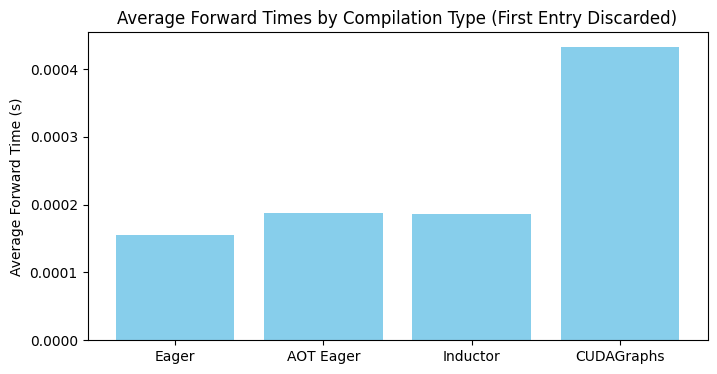

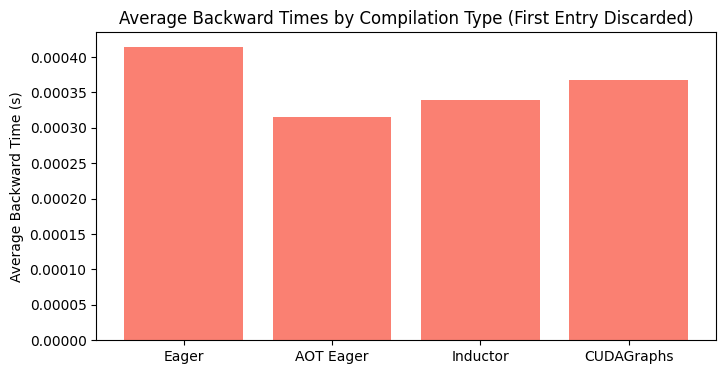

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Discard the first timing (compiled step) from each timing list
forward_times_eager_trimmed = forward_times_eager[1:]
forward_times_aot_eager_trimmed = forward_times_aot_eager[1:]
forward_times_inductor_trimmed = forward_times_inductor[1:]
forward_times_cudagraphs_trimmed = forward_times_cudagraphs[1:]

backward_times_eager_trimmed = backward_times_eager[1:]
backward_times_aot_eager_trimmed = backward_times_aot_eager[1:]
backward_times_inductor_trimmed = backward_times_inductor[1:]
backward_times_cudagraphs_trimmed = backward_times_cudagraphs[1:]

# Calculate means for each compilation type after discarding the first entry
compilation_types = [
    "Eager",
    "AOT Eager",
    "Inductor",
    "CUDAGraphs"
]
forward_means = [
    np.mean(forward_times_eager_trimmed),
    np.mean(forward_times_aot_eager_trimmed),
    np.mean(forward_times_inductor_trimmed),
    np.mean(forward_times_cudagraphs_trimmed)
]
backward_means = [
    np.mean(backward_times_eager_trimmed),
    np.mean(backward_times_aot_eager_trimmed),
    np.mean(backward_times_inductor_trimmed),
    np.mean(backward_times_cudagraphs_trimmed)
]

# Bar chart for forward times
plt.figure(figsize=(8, 4))
plt.bar(compilation_types, forward_means, color='skyblue')
plt.ylabel('Average Forward Time (s)')
plt.title('Average Forward Times by Compilation Type (First Entry Discarded)')
plt.show()

# Bar chart for backward times
plt.figure(figsize=(8, 4))
plt.bar(compilation_types, backward_means, color='salmon')
plt.ylabel('Average Backward Time (s)')
plt.title('Average Backward Times by Compilation Type (First Entry Discarded)')
plt.show()

Why

In [34]:
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

def problem2(x):
    d = {}
    d['key'] = x
    return d['key'] * 2

def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

In [35]:
# compile, fail, why?
p_1 = torch.compile(problem1)
p_2 = torch.compile(problem2)
p_3 = torch.compile(problem3)



In [36]:
def problem1_fix(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

def problem2_fix(x):
    d = {}
    d['key'] = x
    return d['key'] * 2

def problem3_fix(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

In [37]:
class GraphNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1000, 100)
        self.fc2 = nn.Linear(100, 50)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = x + 10
        x = batch_norm(x)
        print(x[0])
        
        return x

model = SimpleNN()
model.to("cuda")

SimpleNN(
  (fc1): Linear(in_features=1000, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=10, bias=True)
)